<a href="https://colab.research.google.com/github/salphonseds/llm-from-scratch/blob/main/notebooks%20/05_Training_and_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Setup + recreate the GPT model from Days 6-7
import torch
import torch.nn as nn
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        batch_size, seq_len, _ = x.shape
        Q = self.W_q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        out = attn_weights @ V
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        return self.W_o(out)


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = x + self.dropout(self.attn(self.ln1(x), mask))
        x = x + self.dropout(self.ff(self.ln2(x)))
        return x


class GPTModel(nn.Module):
    def __init__(self, vocab_size=50257, d_model=512, num_heads=8, d_ff=2048,
                 num_layers=6, max_len=256, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])

        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.token_emb.weight  # weight tying

        self.register_buffer("causal_mask",
            torch.tril(torch.ones(max_len, max_len)).view(1, 1, max_len, max_len))

    def forward(self, idx):
        batch_size, seq_len = idx.shape
        pos = torch.arange(seq_len, device=idx.device).unsqueeze(0)
        x = self.token_emb(idx) + self.pos_emb(pos)
        x = self.dropout(x)
        mask = self.causal_mask[:, :, :seq_len, :seq_len]
        for block in self.blocks:
            x = block(x, mask)
        x = self.ln_f(x)
        return self.lm_head(x)


# Recreate model with your established hyperparameters
torch.manual_seed(42)
model = GPTModel(vocab_size=50257, d_model=512, num_heads=8, d_ff=2048,
                  num_layers=6, max_len=256).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Model recreated: {num_params:,} parameters")
print(f"Expected: 44,777,984 parameters")
print(f"Match: {num_params == 44_777_984}")

Using device: cuda
Model recreated: 44,777,984 parameters
Expected: 44,777,984 parameters
Match: True


In [2]:
# Cell 2 (revised): Fix initialization, then re-check the loss

def _init_weights(module):
    if isinstance(module, nn.Linear):
        nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if module.bias is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, nn.Embedding):
        nn.init.normal_(module.weight, mean=0.0, std=0.02)

# Re-instantiate and apply proper init
torch.manual_seed(42)
model = GPTModel(vocab_size=50257, d_model=512, num_heads=8, d_ff=2048,
                  num_layers=6, max_len=256).to(device)
model.apply(_init_weights)

num_params = sum(p.numel() for p in model.parameters())
print(f"Params: {num_params:,} (should still be 44,777,984)")

# Re-run the same loss check from before
dummy_input = torch.randint(0, 50257, (2, 10)).to(device)
dummy_targets = torch.randint(0, 50257, (2, 10)).to(device)

logits = model(dummy_input)
loss_fn = nn.CrossEntropyLoss()
loss = loss_fn(logits.view(-1, 50257), dummy_targets.view(-1))

print(f"Loss after fix: {loss.item():.4f}")
print(f"Expected (uniform baseline): ln(50257) = {math.log(50257):.4f}")

Params: 44,777,984 (should still be 44,777,984)
Loss after fix: 10.9532
Expected (uniform baseline): ln(50257) = 10.8249


In [3]:
# Cell 3: Tokenize a small corpus + build sliding-window input/target pairs
!pip install tiktoken -q

import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")  # same 50,257-token vocab as our model

# Small original toy corpus - enough text to give the model real patterns to learn
text = """
The old lighthouse stood at the edge of the cliff, its light sweeping
across the dark water every few seconds. Sailors who passed that coast
said the keeper never slept, that he watched the horizon for ships that
would never come. Every winter the storms grew fiercer, and every winter
the lighthouse held its ground. The keeper would climb the spiral stairs
each evening, counting them as he always had, and light the lamp before
the last color drained from the sky. He believed that somewhere out on
the water, someone was always looking back toward the light, grateful
for the proof that land still existed, that the world had not been
swallowed entirely by the sea.
"""

token_ids = tokenizer.encode(text)
print(f"Total tokens: {len(token_ids)}")
print(f"First 20 token ids: {token_ids[:20]}")
print(f"Decoded back: {tokenizer.decode(token_ids[:20])}")

seq_len = 10  # matches the seq_len you've been testing with throughout
stride = 5    # overlapping windows since our corpus is tiny

inputs, targets = [], []
for i in range(0, len(token_ids) - seq_len, stride):
    inputs.append(token_ids[i:i + seq_len])
    targets.append(token_ids[i + 1:i + seq_len + 1])

inputs = torch.tensor(inputs)
targets = torch.tensor(targets)

print(f"\nNumber of training examples: {len(inputs)}")
print(f"Inputs shape: {inputs.shape}, Targets shape: {targets.shape}")
print(f"\nExample pair 0:")
print(f"  Input:  {tokenizer.decode(inputs[0].tolist())!r}")
print(f"  Target: {tokenizer.decode(targets[0].tolist())!r}")

Total tokens: 146
First 20 token ids: [198, 464, 1468, 46371, 6204, 379, 262, 5743, 286, 262, 19516, 11, 663, 1657, 18404, 198, 330, 1214, 262, 3223]
Decoded back: 
The old lighthouse stood at the edge of the cliff, its light sweeping
across the dark

Number of training examples: 28
Inputs shape: torch.Size([28, 10]), Targets shape: torch.Size([28, 10])

Example pair 0:
  Input:  '\nThe old lighthouse stood at the edge of the'
  Target: 'The old lighthouse stood at the edge of the cliff'


In [4]:
# Cell 4: Train on the tiny corpus - watch the loss drop
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)

inputs = inputs.to(device)
targets = targets.to(device)

batch_size = 4
num_epochs = 100
loss_history = []

model.train()
for epoch in range(num_epochs):
    epoch_losses = []
    perm = torch.randperm(len(inputs))  # reshuffle each epoch

    for i in range(0, len(inputs), batch_size):
        idx = perm[i:i + batch_size]
        batch_inputs = inputs[idx]
        batch_targets = targets[idx]

        logits = model(batch_inputs)
        loss = loss_fn(logits.view(-1, 50257), batch_targets.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    loss_history.append(avg_loss)

    if epoch % 10 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f}")

print(f"\nStarting loss (Cell 2): ~10.95")
print(f"Final loss: {loss_history[-1]:.4f}")

Epoch   0 | Loss: 9.8136
Epoch  10 | Loss: 1.1868
Epoch  20 | Loss: 0.1052
Epoch  30 | Loss: 0.0661
Epoch  40 | Loss: 0.0537
Epoch  50 | Loss: 0.0911
Epoch  60 | Loss: 0.0402
Epoch  70 | Loss: 0.0343
Epoch  80 | Loss: 0.0376
Epoch  90 | Loss: 0.0847
Epoch  99 | Loss: 0.0371

Starting loss (Cell 2): ~10.95
Final loss: 0.0371


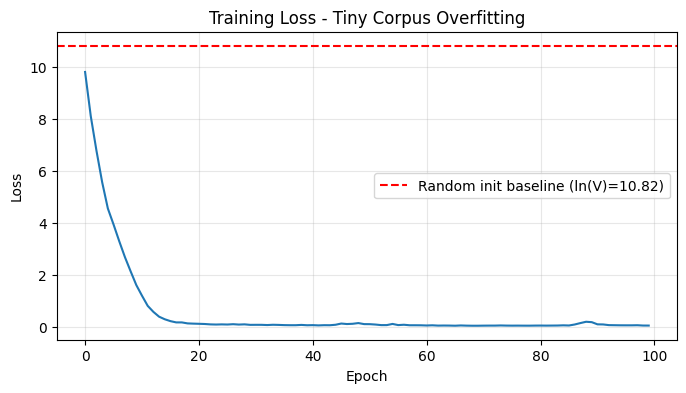

Min loss reached: 0.0312 at epoch 69


In [5]:
# Cell 5: Visualize the training loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss - Tiny Corpus Overfitting")
plt.axhline(y=math.log(50257), color='r', linestyle='--', label=f'Random init baseline (ln(V)={math.log(50257):.2f})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Min loss reached: {min(loss_history):.4f} at epoch {loss_history.index(min(loss_history))}")

In [6]:
# Cell 6: Retrain from scratch with warmup+cosine LR schedule and gradient clipping
torch.manual_seed(42)
model = GPTModel(vocab_size=50257, d_model=512, num_heads=8, d_ff=2048,
                  num_layers=6, max_len=256).to(device)
model.apply(_init_weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)

batch_size = 4
num_epochs = 100
steps_per_epoch = math.ceil(len(inputs) / batch_size)
total_steps = num_epochs * steps_per_epoch
warmup_steps = int(0.1 * total_steps)
max_lr = 3e-4
min_lr = max_lr * 0.1

def get_lr(step):
    if step < warmup_steps:
        return max_lr * (step + 1) / warmup_steps
    progress = min((step - warmup_steps) / max(1, total_steps - warmup_steps), 1.0)
    cosine = 0.5 * (1 + math.cos(math.pi * progress))
    return min_lr + (max_lr - min_lr) * cosine

loss_history_v2 = []
step = 0

model.train()
for epoch in range(num_epochs):
    epoch_losses = []
    perm = torch.randperm(len(inputs))

    for i in range(0, len(inputs), batch_size):
        idx = perm[i:i + batch_size]
        batch_inputs = inputs[idx]
        batch_targets = targets[idx]

        lr = get_lr(step)
        for pg in optimizer.param_groups:
            pg['lr'] = lr

        logits = model(batch_inputs)
        loss = loss_fn(logits.view(-1, 50257), batch_targets.view(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_losses.append(loss.item())
        step += 1

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    loss_history_v2.append(avg_loss)

    if epoch % 10 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f} | LR: {lr:.6f}")

print(f"\nFinal loss (v1, no clip/schedule): {loss_history[-1]:.4f}")
print(f"Final loss (v2, with clip+schedule): {loss_history_v2[-1]:.4f}")

Epoch   0 | Loss: 10.7998 | LR: 0.000030
Epoch  10 | Loss: 2.1550 | LR: 0.000300
Epoch  20 | Loss: 0.0984 | LR: 0.000290
Epoch  30 | Loss: 0.0601 | LR: 0.000266
Epoch  40 | Loss: 0.0413 | LR: 0.000229
Epoch  50 | Loss: 0.0311 | LR: 0.000184
Epoch  60 | Loss: 0.0270 | LR: 0.000138
Epoch  70 | Loss: 0.0280 | LR: 0.000094
Epoch  80 | Loss: 0.0221 | LR: 0.000059
Epoch  90 | Loss: 0.0240 | LR: 0.000037
Epoch  99 | Loss: 0.0260 | LR: 0.000030

Final loss (v1, no clip/schedule): 0.0371
Final loss (v2, with clip+schedule): 0.0260


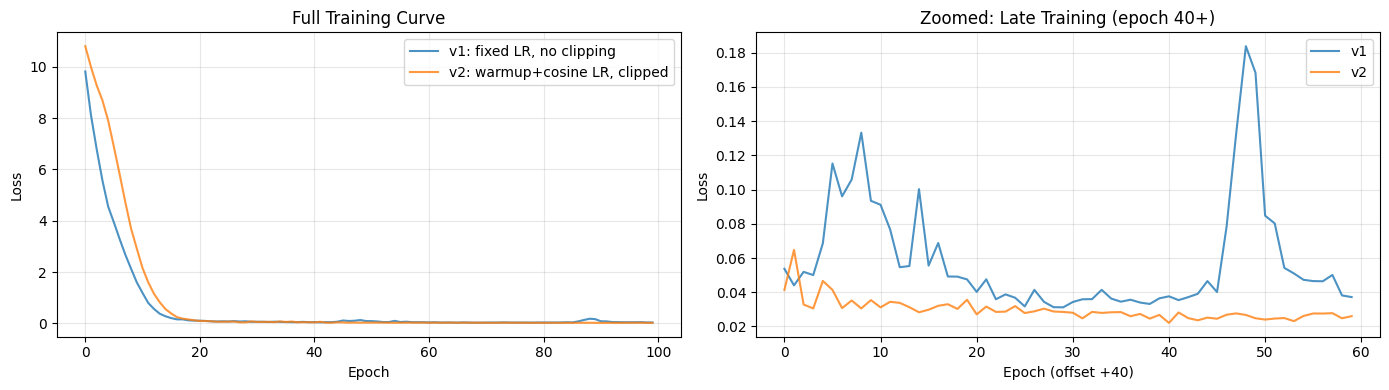

In [7]:
# Cell 7: Compare v1 (no clip/schedule) vs v2 (with clip/schedule)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(loss_history, label='v1: fixed LR, no clipping', alpha=0.8)
axes[0].plot(loss_history_v2, label='v2: warmup+cosine LR, clipped', alpha=0.8)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Full Training Curve")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(loss_history[40:], label='v1', alpha=0.8)
axes[1].plot(loss_history_v2[40:], label='v2', alpha=0.8)
axes[1].set_xlabel("Epoch (offset +40)")
axes[1].set_ylabel("Loss")
axes[1].set_title("Zoomed: Late Training (epoch 40+)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Cell 8: Greedy text generation
def generate(model, idx, max_new_tokens, context_size):
    model.eval()
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]  # crop to max context the model supports
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]  # only care about the prediction for the next token
        next_id = torch.argmax(logits, dim=-1, keepdim=True)
        idx = torch.cat([idx, next_id], dim=1)
    model.train()
    return idx

# Prompt with the start of the original passage
prompt = "The old lighthouse stood"
prompt_ids = torch.tensor([tokenizer.encode(prompt)]).to(device)

generated_ids = generate(model, prompt_ids, max_new_tokens=20, context_size=seq_len)
generated_text = tokenizer.decode(generated_ids[0].tolist())

print(f"Prompt: {prompt!r}")
print(f"Generated: {generated_text!r}")

Prompt: 'The old lighthouse stood'
Generated: 'The old lighthouse stood at the lamp before\nthe last color drained from the sky. The He believed somewhere somewhere out out'


In [9]:
# Cell 9: Summary
print("=" * 60)
print("DAY 8-9 COMPLETE: TRAINING & OPTIMIZATION ✓")
print("=" * 60)

print("\n📚 What we built from scratch:")
print("  1. ✓ GPT-2 style weight initialization (std=0.02)")
print("  2. ✓ Cross-entropy loss for next-token prediction")
print("  3. ✓ Sliding-window tokenization with tiktoken (GPT-2 BPE)")
print("  4. ✓ Training loop: forward -> loss -> backward -> step")
print("  5. ✓ Gradient clipping (global norm)")
print("  6. ✓ LR warmup + cosine decay schedule")
print("  7. ✓ Greedy decoding for text generation")

print("\n🔑 Key concepts mastered:")
print("  • Initialization controls logit variance (esp. with weight tying)")
print("  • ln(vocab_size) is the random-init loss baseline")
print("  • Gradient clipping prevents destabilizing update spikes")
print("  • Warmup+cosine LR smooths convergence vs. fixed LR")
print("  • Greedy decoding is deterministic and prone to repetition loops")
print("  • Small context windows fragment longer-range coherence")

print("\n📊 Results:")
print(f"  • v1 (no clip/schedule) final loss: {loss_history[-1]:.4f}")
print(f"  • v2 (clip+schedule) final loss:    {loss_history_v2[-1]:.4f}")
print(f"  • Random-init baseline:             {math.log(50257):.4f}")

print("\n🎯 Next session preview:")
print("  Day 10: Generation Strategies")
print("    - Temperature sampling")
print("    - Top-k and top-p (nucleus) sampling")
print("    - Beam search")
print("    - Fixing the repetition loop we just saw")

print("\n" + "=" * 60)
print("9/21 days complete (~43%) - save this notebook!")
print("=" * 60)

DAY 8-9 COMPLETE: TRAINING & OPTIMIZATION ✓

📚 What we built from scratch:
  1. ✓ GPT-2 style weight initialization (std=0.02)
  2. ✓ Cross-entropy loss for next-token prediction
  3. ✓ Sliding-window tokenization with tiktoken (GPT-2 BPE)
  4. ✓ Training loop: forward -> loss -> backward -> step
  5. ✓ Gradient clipping (global norm)
  6. ✓ LR warmup + cosine decay schedule
  7. ✓ Greedy decoding for text generation

🔑 Key concepts mastered:
  • Initialization controls logit variance (esp. with weight tying)
  • ln(vocab_size) is the random-init loss baseline
  • Gradient clipping prevents destabilizing update spikes
  • Warmup+cosine LR smooths convergence vs. fixed LR
  • Greedy decoding is deterministic and prone to repetition loops
  • Small context windows fragment longer-range coherence

📊 Results:
  • v1 (no clip/schedule) final loss: 0.0371
  • v2 (clip+schedule) final loss:    0.0260
  • Random-init baseline:             10.8249

🎯 Next session preview:
  Day 10: Generation S